# NB04 — Japanese Consumer Voice
**Signal/Pulse · NLP & Sentiment Analysis**

**Purpose:** Extract what Japanese beauty consumers are actually saying —
not just how many reviews there are (NB05), but *what language they use*
and how that language has shifted since COVID.

**Analytical threads:**
1. NLP environment setup & corpus overview
2. SudachiPy tokenisation pipeline
3. TF-IDF: skincare vs cosmetics vocabulary contrast
4. Vocabulary shift: pre-COVID (2019) vs post-COVID (2022–2025)
5. Ingredient intelligence signal in consumer text
6. Review engagement quality (length, richness)
7. Word clouds — skincare vs cosmetics

**NLP stack:** SudachiPy → scikit-learn TF-IDF → WordCloud

**Output feeds NB05:** The vocabulary shift evidence enriches
the confirmatory shift analysis with qualitative consumer signal.


## 0. Environment Setup


In [2]:
# ── Install check ────────────────────────────────────────────────────────────
# Run this cell first. If anything is missing, run the pip install below,
# restart the kernel, then proceed.

import sys
sys.path.insert(0, "..")

from src.viz import check_nlp_deps
check_nlp_deps()


NB04 — NLP dependency check
--------------------------------------------
  ✓  SudachiPy tokeniser                 0.6.10
  ✓  Sudachi dictionary (core)           ✓
  ✓  scikit-learn (TF-IDF)               1.8.0
  ✓  Japanese font helper                ✓
  ✓  WordCloud (optional, Section 7)     1.9.6

All dependencies satisfied. ✓


## Install command — run in terminal if needed

Run the following in your terminal (conda activate beauty-pulse first):

```
pip install sudachipy sudachidict-full
pip install ginza ja-ginza
pip install scikit-learn
pip install wordcloud
pip install japanize-matplotlib
```

After installing: **Kernel → Restart Kernel → Run All Cells**


In [3]:
import sys
sys.path.insert(0, "..")

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sudachipy import tokenizer as sudachi_tokenizer, dictionary as sudachi_dictionary
from src.schema import get_connection
from src.config import PROJECT, get_exclusion_terms
from src.viz import (
    PALETTE, fig_ax, tight, annotate_covid,
    apply_style, check_nlp_deps, wordcloud_jp
)

apply_style()

conn = get_connection()
print("Dependencies:")
import sudachipy, sklearn
print(f"  sudachipy          : {sudachipy.__version__}")
print(f"  scikit-learn       : {sklearn.__version__}")
print(f"  Font               : {plt.rcParams['font.family']}")
print()
for tbl in ['reviews', 'yt_comments']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f"  {tbl:<20}: {n:>8,} rows")


Font: Yu Gothic ✓
Dependencies:
  sudachipy          : 0.6.10
  scikit-learn       : 1.8.0
  Font               : ['Yu Gothic']

  reviews             :   22,451 rows
  yt_comments         :   60,676 rows


## 1. Corpus Overview

Before tokenising anything, understand what text we have:
character count distribution, language rate, temporal coverage.


In [4]:
sql_corpus = '''
SELECT
    c.tier,
    c.normalized_name                                AS category,
    COUNT(*)                                         AS review_count,
    SUM(CASE WHEN r.review_year IS NOT NULL THEN 1 ELSE 0 END) AS dated_reviews,
    ROUND(AVG(r.char_count), 0)                      AS avg_chars,
    SUM(CASE WHEN r.char_count >= 50 THEN 1 ELSE 0 END)  AS substantive_reviews,
    ROUND(
        100.0 * SUM(CASE WHEN r.char_count >= 50 THEN 1 ELSE 0 END) / COUNT(*),
        1
    ) AS pct_substantive
FROM reviews r
JOIN categories c ON r.category_id = c.category_id
WHERE r.is_japanese = 1
  AND r.review_text IS NOT NULL
GROUP BY c.category_id
ORDER BY c.tier, review_count DESC
'''

df_corpus = pd.read_sql(sql_corpus, conn)
print("Review corpus overview:")
print(df_corpus.to_string(index=False))

total_chars = conn.execute(
    "SELECT SUM(char_count) FROM reviews WHERE is_japanese=1"
).fetchone()[0]
print(f"\nTotal characters in JP review corpus: {total_chars:,}")
print(f"Approx. pages of text (400 chars/page): {total_chars // 400:,}")


Review corpus overview:
     tier       category  review_count  dated_reviews  avg_chars  substantive_reviews  pct_substantive
cosmetics     lip_colour          2223           2056       74.0                 1851             83.3
cosmetics     foundation          1329           1190       73.0                 1113             83.7
cosmetics     eye_shadow           995            894       76.0                  848             85.2
 skincare      face_wash          4425           3961       72.0                 3583             81.0
 skincare       emulsion          4293           3950       74.0                 3602             83.9
 skincare   toner_lotion          3770           3400       74.0                 3121             82.8
 skincare     face_cream          2325           1970       74.0                 1965             84.5
 skincare sun_protection          1113           1056       71.0                  881             79.2
 skincare  serum_essence           889           

Saved → ../outputs/nb04_review_length.png


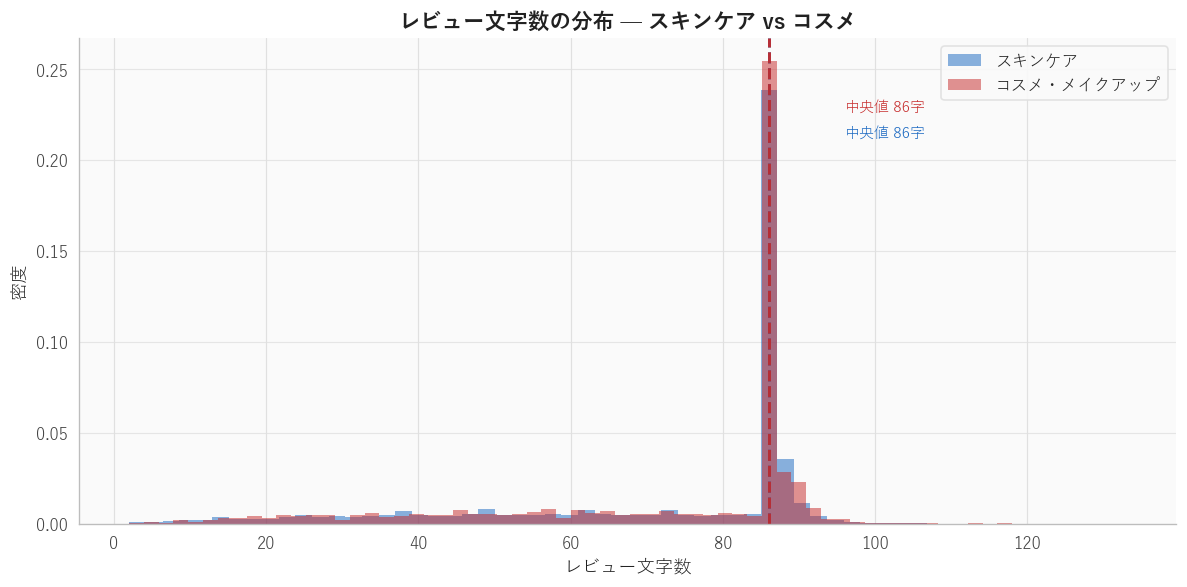

In [5]:
# Chart — review length distribution by tier
sql_length = '''
SELECT c.tier, r.char_count
FROM reviews r
JOIN products p  ON r.product_id  = p.product_id
JOIN categories c ON p.category_id = c.category_id
WHERE r.is_japanese = 1
  AND r.review_text IS NOT NULL
  AND r.char_count > 0
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
'''
df_len = pd.read_sql(sql_length, conn)

fig, ax = fig_ax(10, 5)
for tier, color, label in [
    ('skincare',  PALETTE['skincare'],  'スキンケア'),
    ('cosmetics', PALETTE['cosmetics'], 'コスメ・メイクアップ'),
]:
    d = df_len[df_len.tier == tier]['char_count'].clip(upper=800)
    ax.hist(d, bins=60, alpha=0.5, color=color, label=label,
            density=True, edgecolor='none')
    med = d.median()
    ax.axvline(med, color=color, linewidth=1.8, linestyle='--', alpha=0.9)
    ax.text(med + 10, ax.get_ylim()[1] * 0.85,
            f"中央値 {med:.0f}字", color=color, fontsize=9)

ax.set_xlabel("レビュー文字数", fontsize=11)
ax.set_ylabel("密度", fontsize=11)
ax.set_title("レビュー文字数の分布 — スキンケア vs コスメ", fontsize=13)
ax.legend(fontsize=10)
tight(fig, "../outputs/nb04_review_length.png")
plt.show()


Saved → ../outputs/nb04_corpus_distribution.png


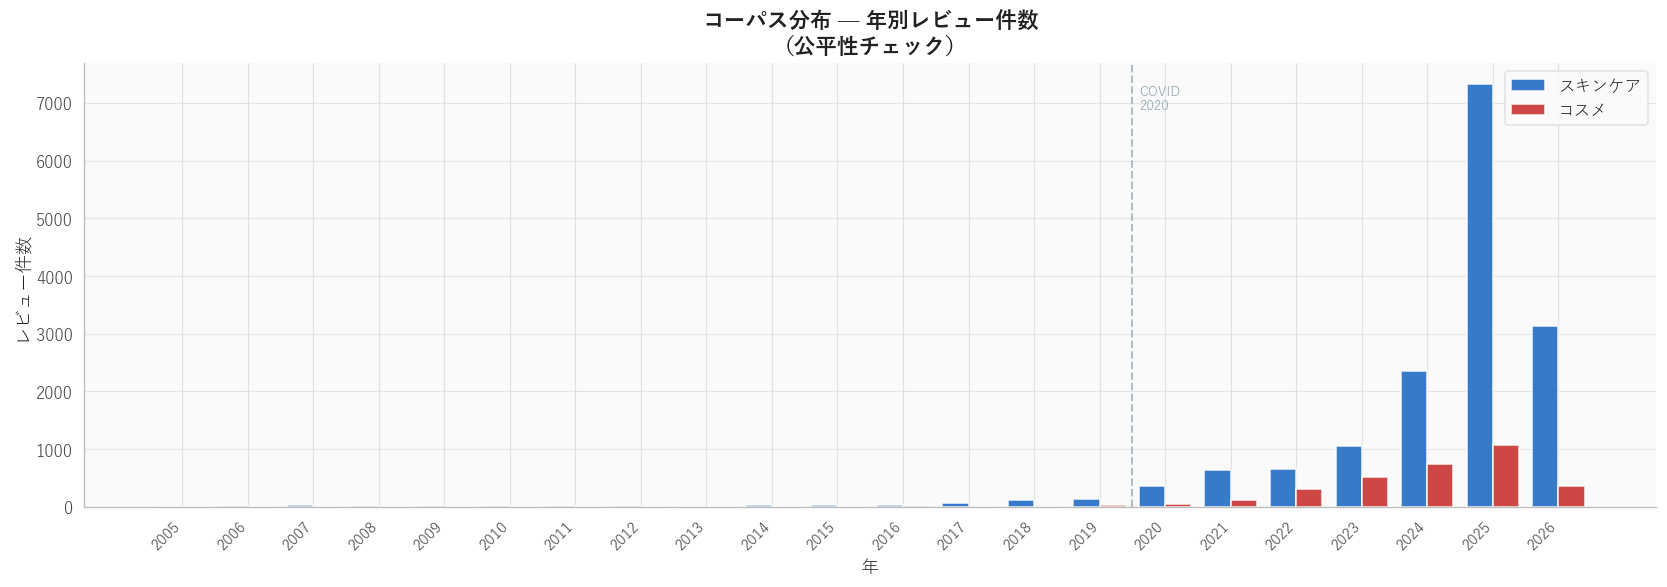


Corpus distribution:
tier         cosmetics  skincare
review_year                     
2005                 0         4
2006                 0        22
2007                 0        27
2008                 0        23
2009                 0        15
2010                 0        17
2011                 1        12
2012                 0        11
2013                 1         3
2014                 4        24
2015                 0        36
2016                 7        33
2017                 0        59
2018                 6       111
2019                24       144
2020                48       363
2021               122       647
2022               304       651
2023               526      1058
2024               738      2355
2025              1069      7323
2026               366      3138


In [6]:
sql_dist = '''
SELECT
    review_year,
    c.tier,
    COUNT(*) AS review_count
FROM reviews r
JOIN products p   ON r.product_id  = p.product_id
JOIN categories c ON p.category_id = c.category_id
WHERE r.review_year BETWEEN 2005 AND 2026
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
  AND r.review_year IS NOT NULL
GROUP BY review_year, c.tier
ORDER BY review_year
'''

df_dist = pd.read_sql(sql_dist, conn)

skin = df_dist[df_dist.tier == 'skincare'].set_index('review_year')['review_count']
cosm = df_dist[df_dist.tier == 'cosmetics'].set_index('review_year')['review_count']
years = sorted(df_dist.review_year.unique())

fig, ax = fig_ax(14, 5)
x = np.arange(len(years))
w = 0.4
ax.bar(x - w/2, [skin.get(y, 0) for y in years], w,
       color=PALETTE['skincare'], alpha=0.85, label='スキンケア')
ax.bar(x + w/2, [cosm.get(y, 0) for y in years], w,
       color=PALETTE['cosmetics'], alpha=0.85, label='コスメ')

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('年', fontsize=11)
ax.set_ylabel('レビュー件数', fontsize=11)
ax.set_title('コーパス分布 — 年別レビュー件数\n（公平性チェック）', fontsize=13)
ax.axvline(x[years.index(2019)] + 0.5, color='#90A4AE',
           linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(x[years.index(2019)] + 0.6, ax.get_ylim()[1] * 0.95,
        'COVID\n2020', fontsize=8, color='#90A4AE', va='top')
ax.legend(fontsize=10)
tight(fig, '../outputs/nb04_corpus_distribution.png')
plt.show()

print('\nCorpus distribution:')
print(df_dist.pivot(index='review_year', columns='tier', values='review_count')
      .fillna(0).astype(int).to_string())


## 2. Tokenisation Pipeline — SudachiPy

SudachiPy is the gold-standard Japanese tokeniser used in production
at Yahoo Japan and LINE. Dictionary mode C provides aggressive
compound-word splitting — correct for beauty ingredient terminology.


In [7]:
import sudachipy
from sudachipy import tokenizer as suda_tokenizer, dictionary as suda_dict

# Initialise tokeniser — mode C
tokenizer_obj = suda_dict.Dictionary().create()
mode = suda_tokenizer.Tokenizer.SplitMode.C

# ── Stopwords ─────────────────────────────────────────────────────────────
# Four layers:
# 1. Generic Japanese function words
# 2. Generic review meta-language (in every review regardless of topic)
# 3. E-commerce / platform noise
# 4. Corpus contamination (LDA-identified noise clusters)
BASE_STOPWORDS = {
    # Function words
    'する', 'なる', 'ある', 'いる', 'れる', 'られる', 'くれる', 'もらう',
    'いただく', 'できる', 'です', 'ます', 'でした', 'ました', 'ない',
    'もの', 'こと', 'よう', 'ため', 'とき', 'ところ', 'わけ', 'はず',
    'これ', 'それ', 'あれ', 'どれ', 'ここ', 'そこ', 'あそこ',

    # Generic verbs — appear in ALL reviews, carry no topic signal
    '使う', '思う', '感じる', '見る', '買う', '付ける', '塗る', '試す',
    '続ける', '始める', '終わる', '入る', '出る', '来る', '行く', '知る',
    '分かる', 'もらえる', 'くれる', '欲しい', '良い', 'いい',

    # Generic adjectives — too broad to distinguish topic
    '多い', '少ない', '大きい', '小さい', '長い', '短い', '新しい', '古い',
    '高い', '安い',

    # Generic adverbs
    'とても', 'すごく', 'かなり', 'ちょっと', 'やっぱり', 'やはり',
    'なかなか', 'ちゃんと', 'あまり', 'もっと', 'すこし', '少し',
    '本当に', 'とにかく', 'しっかり', 'ちゃんと', 'まあまあ',

    # Generic sentiment — hiragana forms missed by kanji stopwords
    'よい',       # hiragana form of 良い
    'すごい',     # generic amazement
    'いい',       # already above but confirm

    # Review meta-language
    '商品', '購入', 'レビュー', 'クチコミ', '感想', '使用', '確認',
    '自分', '今回', '今まで', 'いつも', '毎日', '毎回', 'また',
    '普通', '一般', 'こちら', 'そちら', 'もの', 'ところ',
    '星', '評価', 'まず', '次に', 'そして', 'ただ', 'でも',
    'リピート', 'リピ',   # "repeat purchase" — ubiquitous meta-language
    '値段',                # price mentions — too generic

    # E-commerce / platform noise
    '送料', '無料', 'ポイント', 'クーポン', 'セット', 'まとめ', '定期',
    'お試し', 'サンプル', '楽天', 'アマゾン', '公式', 'ショップ',
    'コスメ', 'プレゼント', 'ギフト', 'コスメティック',
    '感じ', '感覚', 'アット',
    '当選',   # @cosme giveaway template noise (LDA Skin T4)

    # Corpus contamination — LDA-identified noise clusters
    '靴下', '暖かい', '冷え性', '冷える', 'あったかい',  # foot care (Cosm T3)
    'ティッシュ', '花粉症', '鼻水',                         # nasal care (Cluster 8)
    'シャンプー', 'トリートメント', '髪質',                   # haircare (Cluster 26)
}

try:
    BASE_STOPWORDS.update(set(get_exclusion_terms()))
except Exception as e:
    print(f"WARNING: get_exclusion_terms() failed — {e}")
    print("Proceeding with base stopwords only.")


def tokenise(text: str,
             pos_filter: set = None,
             stopwords: set = BASE_STOPWORDS) -> list:
    """
    Tokenise Japanese text for TF-IDF vocabulary analysis.
    POS filter: nouns + adjectives only (verbs/adverbs too generic for topic discovery).

    NOTE: SudachiPy mode C splits compound ingredient names
    (e.g. ナイアシンアミド → ナイアシン + アミド).
    TF-IDF therefore will not surface full compound ingredient terms.
    Ingredient signal is measured on raw text in Section 5, not on tokens.
    """
    if pos_filter is None:
        pos_filter = {'名詞', '形容詞'}  # nouns + adjectives only
    if not text or len(text) < 3:
        return []
    tokens = []
    for m in tokenizer_obj.tokenize(text, mode):
        pos = m.part_of_speech()[0]
        if pos not in pos_filter:
            continue
        surface = m.dictionary_form()
        if len(surface) < 2:
            continue
        if surface in stopwords:
            continue
        tokens.append(surface)
    return tokens


# ── Smoke test
test = "化粧水を使い続けて1ヶ月。セラミドとヒアルロン酸のおかげで乾燥肌が改善されました。当選してリピートしました。"
print(f"Input : {test}")
print(f"Tokens: {tokenise(test)}")
print()
print("Expected: セラミド, ヒアルロン, 乾燥, 肌 — NOT 当選, リピート")
print()
print("Tokeniser ready.")


Input : 化粧水を使い続けて1ヶ月。セラミドとヒアルロン酸のおかげで乾燥肌が改善されました。当選してリピートしました。
Tokens: ['化粧水', 'ヶ月', 'セラミド', 'ヒアルロン', 'おかげ', '乾燥肌', '改善']

Expected: セラミド, ヒアルロン, 乾燥, 肌 — NOT 当選, リピート

Tokeniser ready.


In [8]:
from src.schema import get_connection
conn = get_connection()

In [9]:
# ── Batch tokenise full review corpus ─────────────────────────────────────────
sql_reviews = '''
SELECT
    r.review_id,
    r.review_text,
    r.review_year,
    r.rating,
    c.tier,
    c.normalized_name AS category
FROM reviews r
JOIN products p  ON r.product_id  = p.product_id
JOIN categories c ON p.category_id = c.category_id
WHERE r.is_japanese = 1
  AND r.review_text IS NOT NULL
  AND r.char_count >= 20
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
ORDER BY r.review_id
'''

df_reviews = pd.read_sql(sql_reviews, conn)
print(f"Reviews to tokenise: {len(df_reviews):,}")
print("Tokenising... (2-5 minutes on ~22k reviews)")

df_reviews['tokens'] = df_reviews['review_text'].apply(tokenise)
df_reviews['token_count'] = df_reviews['tokens'].apply(len)

print(f"Done. Avg tokens per review: {df_reviews.token_count.mean():.1f}")
print(f"Total tokens: {df_reviews.token_count.sum():,}")
print(f"Reviews with 0 tokens: {(df_reviews.token_count == 0).sum()}")


Reviews to tokenise: 20,622
Tokenising... (2-5 minutes on ~22k reviews)
Done. Avg tokens per review: 6.8
Total tokens: 141,192
Reviews with 0 tokens: 121


## 3. TF-IDF — Skincare vs Cosmetics Vocabulary Contrast

TF-IDF surfaces terms that are *characteristically* associated with each tier —
not just frequent, but distinctively frequent relative to the other.

**The core question: what language distinguishes skincare reviews from cosmetics reviews?**


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_nlp = df_reviews[df_reviews.token_count >= 3].copy()
df_nlp['token_str'] = df_nlp['tokens'].apply(lambda t: ' '.join(t))

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
tfidf_matrix = vectorizer.fit_transform(df_nlp['token_str'])
vocab = vectorizer.get_feature_names_out()
print(f"TF-IDF vocabulary: {len(vocab):,} terms")

# Mean TF-IDF per tier
skin_mask = (df_nlp['tier'] == 'skincare').values
cosm_mask = (df_nlp['tier'] == 'cosmetics').values

import scipy.sparse as sp
skin_mean = np.asarray(tfidf_matrix[skin_mask].mean(axis=0)).flatten()
cosm_mean = np.asarray(tfidf_matrix[cosm_mask].mean(axis=0)).flatten()

def top_terms(scores, vocab, n=30):
    idx = np.argsort(scores)[::-1][:n]
    return [(vocab[i], float(scores[i])) for i in idx]

skin_top = top_terms(skin_mean, vocab)
cosm_top = top_terms(cosm_mean, vocab)

print("\nTop 15 skincare terms:")
for t, s in skin_top[:15]:
    print(f"  {t:<22} {s:.4f}")
print("\nTop 15 cosmetics terms:")
for t, s in cosm_top[:15]:
    print(f"  {t:<22} {s:.4f}")


TF-IDF vocabulary: 5,000 terms

Top 15 skincare terms:
  香り                     0.0199
  乾燥                     0.0163
  保湿                     0.0157
  メイク                    0.0154
  クリーム                   0.0135
  洗顔                     0.0133
  効果                     0.0128
  化粧水                    0.0114
  マスカラ                   0.0113
  クレンジング                 0.0102
  テクスチャー                 0.0101
  柔らかい                   0.0101
  使用感                    0.0100
  タイプ                    0.0100
  洗い上がり                  0.0098

Top 15 cosmetics terms:
  パウダー                   0.0508
  細い                     0.0229
  乾燥                     0.0194
  パフ                     0.0180
  ツヤ                     0.0150
  マット                    0.0143
  ブラシ                    0.0139
  仕上がり                   0.0136
  眉毛                     0.0135
  毛穴                     0.0127
  本当                     0.0123
  口コミ                    0.0115
  細かい                    0.0112
  眉尻                    

Saved → ../outputs/nb04_tfidf_contrast.png


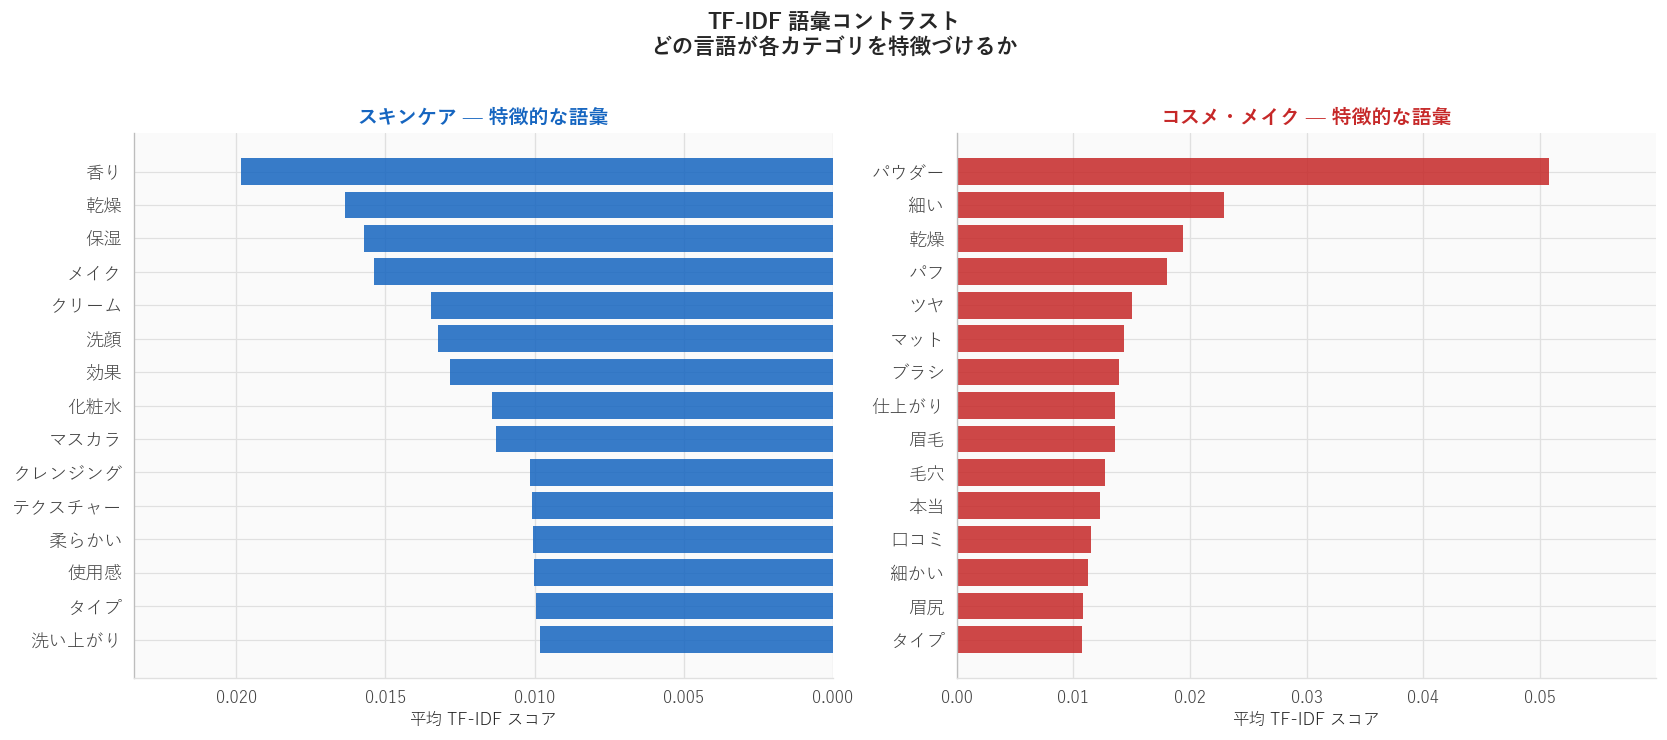

In [11]:
# Chart — vocabulary contrast (back-to-back bars)
n_show = 15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

s_terms  = [t for t, _ in skin_top[:n_show]]
s_scores = [s for _, s in skin_top[:n_show]]
ax1.barh(range(n_show), s_scores[::-1],
         color=PALETTE['skincare'], alpha=0.85, edgecolor='none')
ax1.set_yticks(range(n_show))
ax1.set_yticklabels(s_terms[::-1], fontsize=11)
ax1.set_xlabel("平均 TF-IDF スコア", fontsize=10)
ax1.set_title("スキンケア — 特徴的な語彙", fontsize=12,
              color=PALETTE['skincare'], fontweight='bold')
ax1.invert_xaxis()
ax1.set_xlim(max(s_scores) * 1.18, 0)
ax1.tick_params(left=False)
ax1.set_facecolor(PALETTE['bg'])
ax1.grid(axis='x', color=PALETTE['grid'], linewidth=0.8)
ax1.spines['bottom'].set_color(PALETTE['grid'])

c_terms  = [t for t, _ in cosm_top[:n_show]]
c_scores = [s for _, s in cosm_top[:n_show]]
ax2.barh(range(n_show), c_scores[::-1],
         color=PALETTE['cosmetics'], alpha=0.85, edgecolor='none')
ax2.set_yticks(range(n_show))
ax2.set_yticklabels(c_terms[::-1], fontsize=11)
ax2.set_xlabel("平均 TF-IDF スコア", fontsize=10)
ax2.set_title("コスメ・メイク — 特徴的な語彙", fontsize=12,
              color=PALETTE['cosmetics'], fontweight='bold')
ax2.set_xlim(0, max(c_scores) * 1.18)
ax2.tick_params(left=False)
ax2.set_facecolor(PALETTE['bg'])
ax2.grid(axis='x', color=PALETTE['grid'], linewidth=0.8)
ax2.spines['bottom'].set_color(PALETTE['grid'])

fig.suptitle("TF-IDF 語彙コントラスト\nどの言語が各カテゴリを特徴づけるか",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3)
tight(fig, "../outputs/nb04_tfidf_contrast.png")
plt.show()


## 4. Vocabulary Shift — Pre vs Post-COVID

Has the *language* of skincare reviews changed since COVID, not just the volume?
Rising ingredient terminology = direct evidence of the medicalisation shift.

**Methodology:** One TF-IDF vectorizer fit on the combined pre + post corpus,
then separate mean score vectors per period. Delta = post − pre.
This ensures scores are directly comparable across periods with different corpus sizes.

**Note:** SudachiPy mode C splits compound ingredient names (ナイアシンアミド →
ナイアシン + アミド), so full ingredient compounds will not appear in the token-based
TF-IDF output. Ingredient signal is measured on raw review text in Section 5.

2020 excluded as transition year — comparison is ≤2019 vs ≥2021.


In [12]:
df_skin = df_nlp[df_nlp.tier == 'skincare'].copy()
# 2020 excluded as transition year — comparison is ≤2019 vs ≥2021
df_pre  = df_skin[df_skin.review_year.notna() & (df_skin.review_year <= 2019)]
df_post = df_skin[df_skin.review_year.notna() & (df_skin.review_year >= 2021)]

print(f"Pre-COVID  (≤2019) : {len(df_pre):,} reviews")
print(f"Post-COVID (2021+) : {len(df_post):,} reviews")
if len(df_pre) < 200:
    print("⚠ Pre-COVID corpus small — interpret direction, not magnitude")

# ── Single vectorizer fit on combined corpus ──────────────────────────────
# Both periods share the same vocabulary and IDF weights — scores are comparable.
# This is the correct approach when corpus sizes differ significantly.
shift_vec = TfidfVectorizer(
    max_features=3000, min_df=3, max_df=0.85,
    ngram_range=(1, 2), sublinear_tf=True
)
all_texts = df_pre['token_str'].tolist() + df_post['token_str'].tolist()
shift_vec.fit(all_texts)
vocab_arr = shift_vec.get_feature_names_out()

pre_mean  = np.asarray(shift_vec.transform(df_pre['token_str']).mean(axis=0)).flatten()
post_mean = np.asarray(shift_vec.transform(df_post['token_str']).mean(axis=0)).flatten()
delta     = post_mean - pre_mean

rising_idx   = np.argsort(delta)[::-1][:20]
declining_idx = np.argsort(delta)[:20]

emerging  = [(vocab_arr[i], float(delta[i])) for i in rising_idx]
declining = [(vocab_arr[i], float(delta[i])) for i in declining_idx]

print("\nEMERGING — highest positive delta (post-COVID vs pre-COVID):")
for t, s in emerging[:15]:
    print(f"  {t:<22} Δ={s:+.4f}")
print("\nDECLINING — highest negative delta:")
for t, s in declining[:15]:
    print(f"  {t:<22} Δ={s:+.4f}")


Pre-COVID  (≤2019) : 519 reviews
Post-COVID (2021+) : 13,305 reviews

EMERGING — highest positive delta (post-COVID vs pre-COVID):
  クリーム                   Δ=+0.0148
  保湿                     Δ=+0.0146
  香り                     Δ=+0.0144
  洗顔                     Δ=+0.0140
  乾燥                     Δ=+0.0132
  洗い上がり                  Δ=+0.0113
  トーン                    Δ=+0.0102
  オイル                    Δ=+0.0098
  日焼け                    Δ=+0.0097
  伸び                     Δ=+0.0093
  トーン アップ                Δ=+0.0092
  テクスチャー                 Δ=+0.0082
  美容                     Δ=+0.0079
  リニューアル                 Δ=+0.0075
  アップ                    Δ=+0.0074

DECLINING — highest negative delta:
  カール                    Δ=-0.0495
  マスカラ                   Δ=-0.0433
  キープ                    Δ=-0.0267
  まつげ                    Δ=-0.0237
  カール キープ                Δ=-0.0216
  ブラシ                    Δ=-0.0213
  睫毛                     Δ=-0.0210
  柔らかい                   Δ=-0.0202
  ビューラー                  Δ=

Saved → ../outputs/nb04_vocab_shift.png


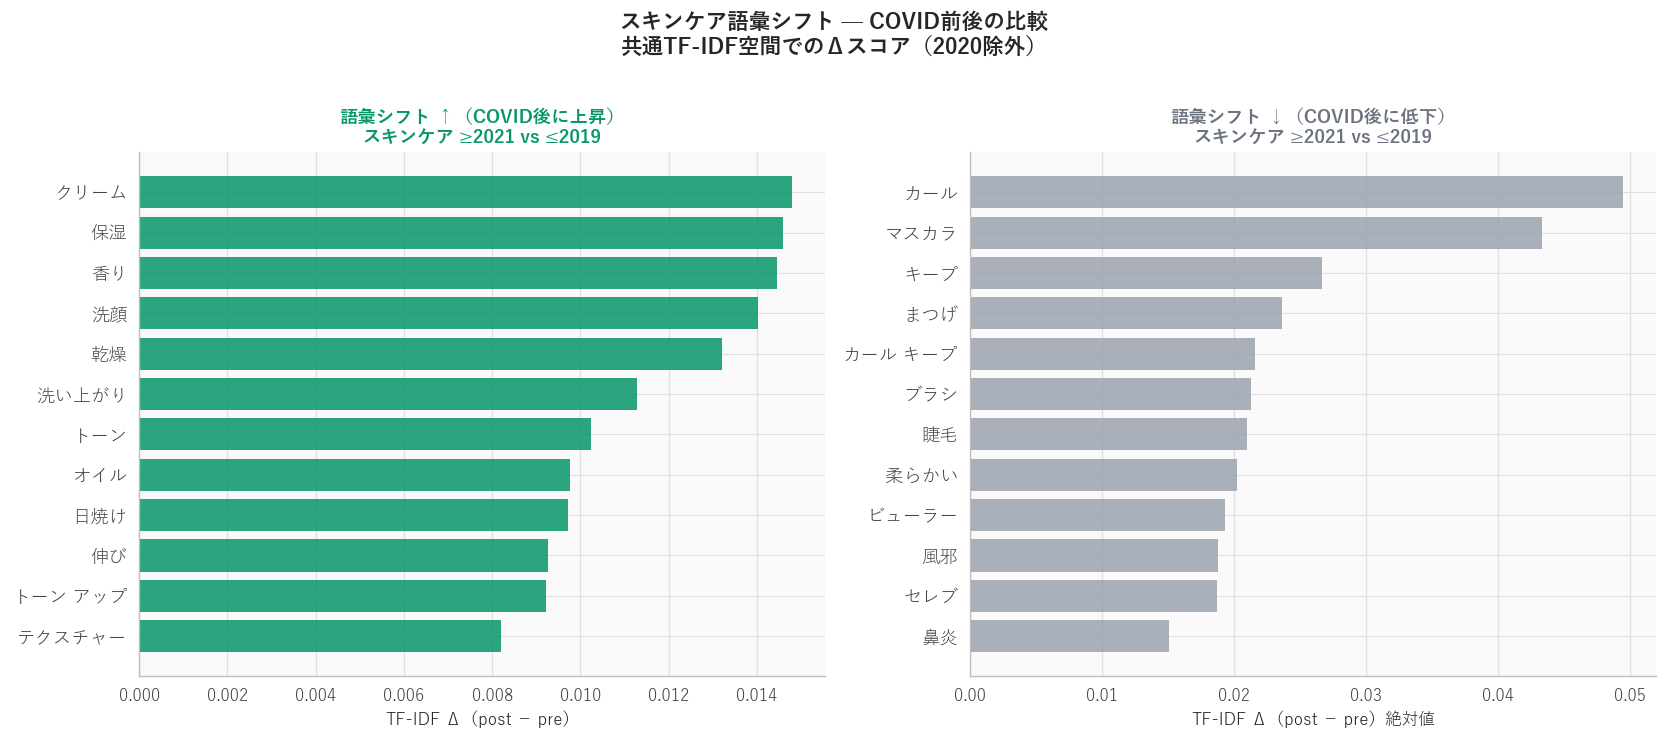

In [13]:
# Chart — vocabulary shift (signed delta from shared TF-IDF space)
n_show = 12
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

e_terms  = [t for t, _ in emerging[:n_show]]
e_scores = [s for _, s in emerging[:n_show]]
ax1.barh(range(len(e_terms)), [abs(s) for s in e_scores[::-1]],
         color='#059669', alpha=0.85, edgecolor='none')
ax1.set_yticks(range(len(e_terms)))
ax1.set_yticklabels(e_terms[::-1], fontsize=11)
ax1.set_xlabel("TF-IDF Δ（post − pre）", fontsize=10)
ax1.set_title("語彙シフト ↑（COVID後に上昇）\nスキンケア ≥2021 vs ≤2019", fontsize=11,
              color='#059669', fontweight='bold')
ax1.tick_params(left=False)
ax1.set_facecolor(PALETTE['bg'])
ax1.grid(axis='x', color=PALETTE['grid'], linewidth=0.8)

d_terms  = [t for t, _ in declining[:n_show]]
d_scores = [s for _, s in declining[:n_show]]
ax2.barh(range(len(d_terms)), [abs(s) for s in d_scores[::-1]],
         color='#9CA3AF', alpha=0.85, edgecolor='none')
ax2.set_yticks(range(len(d_terms)))
ax2.set_yticklabels(d_terms[::-1], fontsize=11)
ax2.set_xlabel("TF-IDF Δ（post − pre）絶対値", fontsize=10)
ax2.set_title("語彙シフト ↓（COVID後に低下）\nスキンケア ≥2021 vs ≤2019", fontsize=11,
              color='#6B7280', fontweight='bold')
ax2.tick_params(left=False)
ax2.set_facecolor(PALETTE['bg'])
ax2.grid(axis='x', color=PALETTE['grid'], linewidth=0.8)

fig.suptitle("スキンケア語彙シフト — COVID前後の比較\n共通TF-IDF空間でのΔスコア（2020除外）",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3)
tight(fig, '../outputs/nb04_vocab_shift.png')
plt.show()


## 5. Ingredient Intelligence Signal

Do ingredient-specific terms appear more frequently in post-COVID reviews?
Tests the medicalisation hypothesis in *consumer writing*, not just search data.


In [14]:
INGREDIENT_TERMS = [
    # Specific ingredient names — search raw text (tokeniser splits compounds)
    'セラミド', 'ナイアシンアミド', 'レチノール', 'レチナール',
    'ヒアルロン酸', 'ビタミンC', 'トラネキサム酸', 'アゼライン酸',
    'グルタチオン', 'エクソソーム', 'ペプチド', 'コラーゲン',
    'AHA', 'BHA', 'コウジ酸', 'アルブチン', 'ニールワン',
    # Function/concept terms — these tokenise fine as single tokens
    '成分', '有効成分', '配合', '浸透', '美白', '保湿', '抗酸化',
]

# ── IMPORTANT: search raw review_text, NOT tokens ─────────────────────────
# SudachiPy mode C splits ナイアシンアミド → ナイアシン + アミド
# Ingredient matching on tokens therefore misses compound ingredient names
# Raw text search is exact and reliable

df_skin2 = df_reviews[
    (df_reviews.tier == 'skincare') & df_reviews.review_year.notna()
].copy()

def has_ingredient(text: str) -> int:
    """Search raw text for any ingredient term. Returns 1 if found, 0 if not."""
    if not text:
        return 0
    return int(any(term in text for term in INGREDIENT_TERMS))

df_skin2['has_ingredient'] = df_skin2['review_text'].apply(has_ingredient)

ing_yr = df_skin2.groupby('review_year').agg(
    n=('review_id', 'count'),
    ing_n=('has_ingredient', 'sum'),
).reset_index()
ing_yr['ing_pct'] = (100 * ing_yr['ing_n'] / ing_yr['n']).round(1)

print("Ingredient mention rate by year (skincare reviews):")
print("(searching raw review text — not tokenised tokens)")
print()
print(ing_yr[ing_yr.review_year.between(2019, 2025)].to_string(index=False))
print()
pre  = ing_yr[ing_yr.review_year <= 2019]['ing_pct'].mean()
post = ing_yr[ing_yr.review_year >= 2021]['ing_pct'].mean()
print(f"Pre-COVID avg  (≤2019) : {pre:.1f}%")
print(f"Post-COVID avg (2021+) : {post:.1f}%")
print(f"Direction: {'↑ increase' if post > pre else '↓ decrease'} ({post-pre:+.1f}pp)")


Ingredient mention rate by year (skincare reviews):
(searching raw review text — not tokenised tokens)

 review_year    n  ing_n  ing_pct
      2019.0  144      6      4.2
      2020.0  351     14      4.0
      2021.0  624     32      5.1
      2022.0  619     24      3.9
      2023.0 1015     47      4.6
      2024.0 2261    265     11.7
      2025.0 7041    826     11.7

Pre-COVID avg  (≤2019) : 5.5%
Post-COVID avg (2021+) : 8.7%
Direction: ↑ increase (+3.3pp)


Saved → ../outputs/nb04_ingredient_rate.png


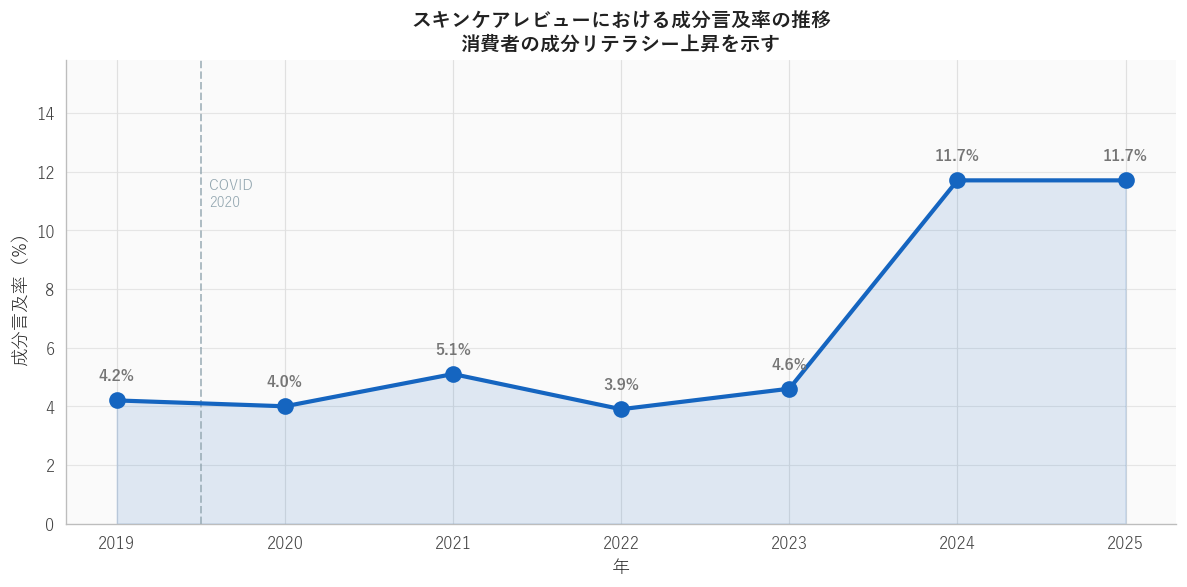

In [15]:
# Chart — ingredient mention rate over time
df_plot = ing_yr[ing_yr.review_year.between(2019, 2025)].copy()

fig, ax = fig_ax(10, 5)
ax.fill_between(df_plot.review_year, df_plot.ing_pct,
                alpha=0.12, color=PALETTE['skincare'])
ax.plot(df_plot.review_year, df_plot.ing_pct,
        'o-', color=PALETTE['skincare'], linewidth=2.5, markersize=9)

for _, row in df_plot.iterrows():
    ax.annotate(f"{row.ing_pct:.1f}%",
                (row.review_year, row.ing_pct),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=9.5, color=PALETTE['text_secondary'],
                fontweight='bold')

annotate_covid(ax, x=2019.5, label="COVID\n2020")
ax.set_xlabel("年", fontsize=11)
ax.set_ylabel("成分言及率（%）", fontsize=11)
ax.set_title("スキンケアレビューにおける成分言及率の推移\n消費者の成分リテラシー上昇を示す",
             fontsize=12)
ax.set_ylim(0, df_plot.ing_pct.max() * 1.35)
tight(fig, "../outputs/nb04_ingredient_rate.png")
plt.show()


## 6. Review Engagement Quality


Saved → ../outputs/nb04_review_quality.png


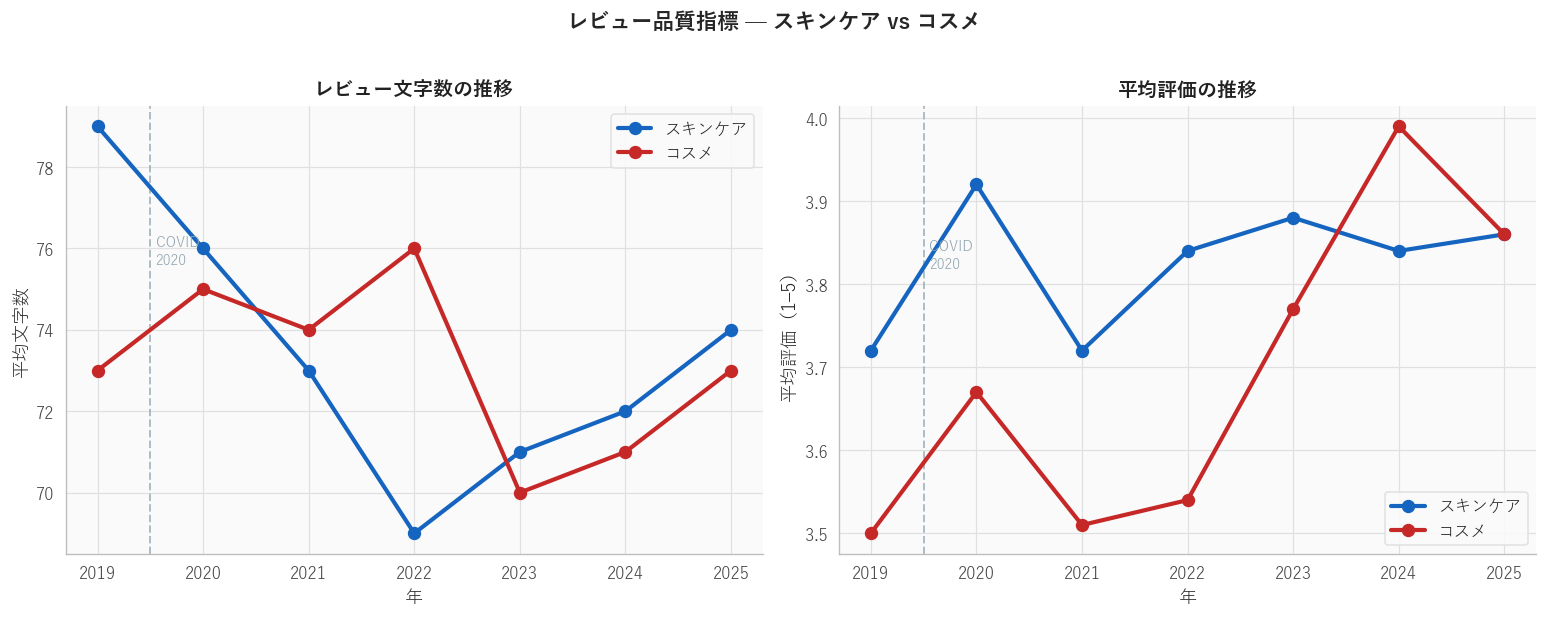

In [16]:
sql_quality = '''
SELECT
    r.review_year,
    c.tier,
    COUNT(*)                        AS review_count,
    ROUND(AVG(r.char_count), 0)     AS avg_chars,
    ROUND(AVG(r.rating), 2)         AS avg_rating
FROM reviews r
JOIN products p  ON r.product_id  = p.product_id
JOIN categories c ON p.category_id = c.category_id
WHERE r.is_japanese = 1
  AND r.char_count >= 10
  AND r.review_year BETWEEN 2019 AND 2025
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
GROUP BY r.review_year, c.tier
ORDER BY c.tier, r.review_year
'''
df_quality = pd.read_sql(sql_quality, conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

for tier, color, label in [
    ('skincare',  PALETTE['skincare'],  'スキンケア'),
    ('cosmetics', PALETTE['cosmetics'], 'コスメ'),
]:
    d = df_quality[df_quality.tier == tier].set_index('review_year')
    ax1.plot(d.index, d['avg_chars'], 'o-', color=color,
             linewidth=2.5, markersize=7, label=label)
    ax2.plot(d.index, d['avg_rating'], 'o-', color=color,
             linewidth=2.5, markersize=7, label=label)

for ax, ylabel, title in [
    (ax1, "平均文字数", "レビュー文字数の推移"),
    (ax2, "平均評価（1–5）", "平均評価の推移"),
]:
    annotate_covid(ax, x=2019.5)
    ax.set_xlabel("年", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.set_facecolor(PALETTE['bg'])

fig.suptitle("レビュー品質指標 — スキンケア vs コスメ",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
tight(fig, '../outputs/nb04_review_quality.png')
plt.show()


## 7. Word Clouds


Saved → ../outputs/nb04_wordcloud_skincare.png


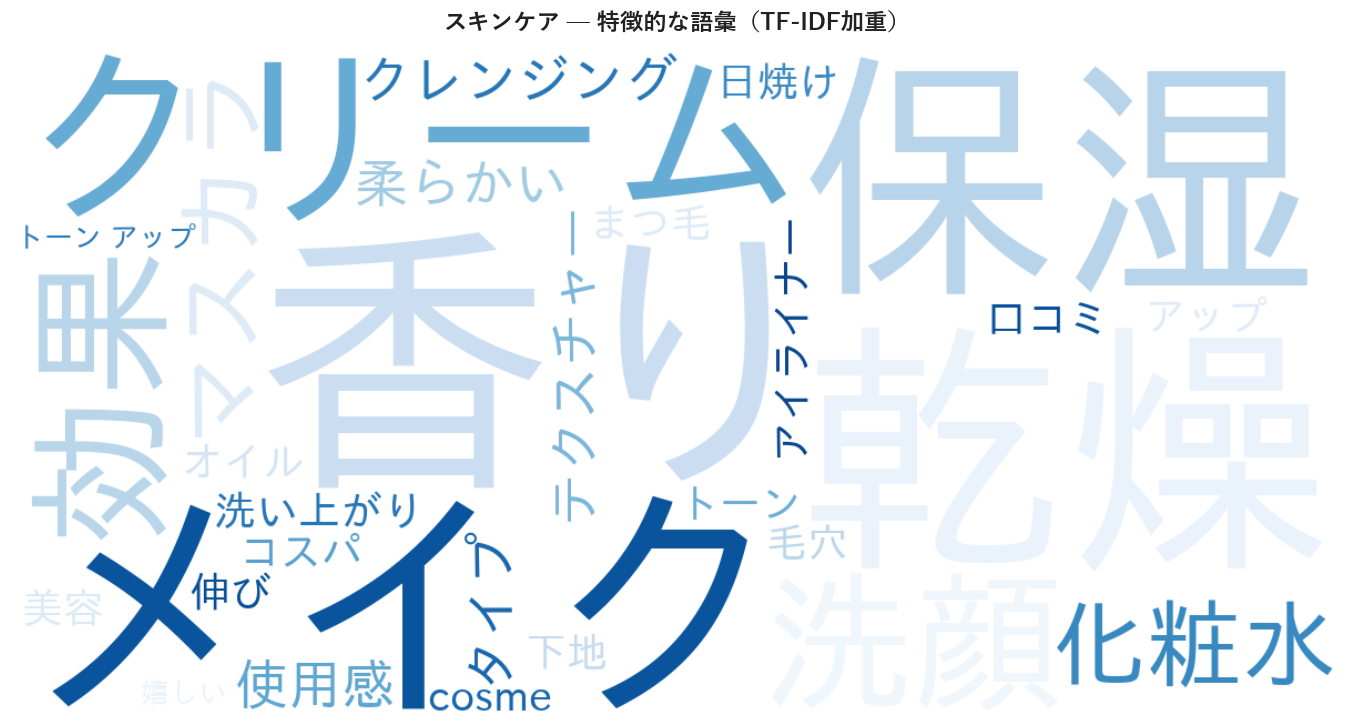

Saved → ../outputs/nb04_wordcloud_cosmetics.png


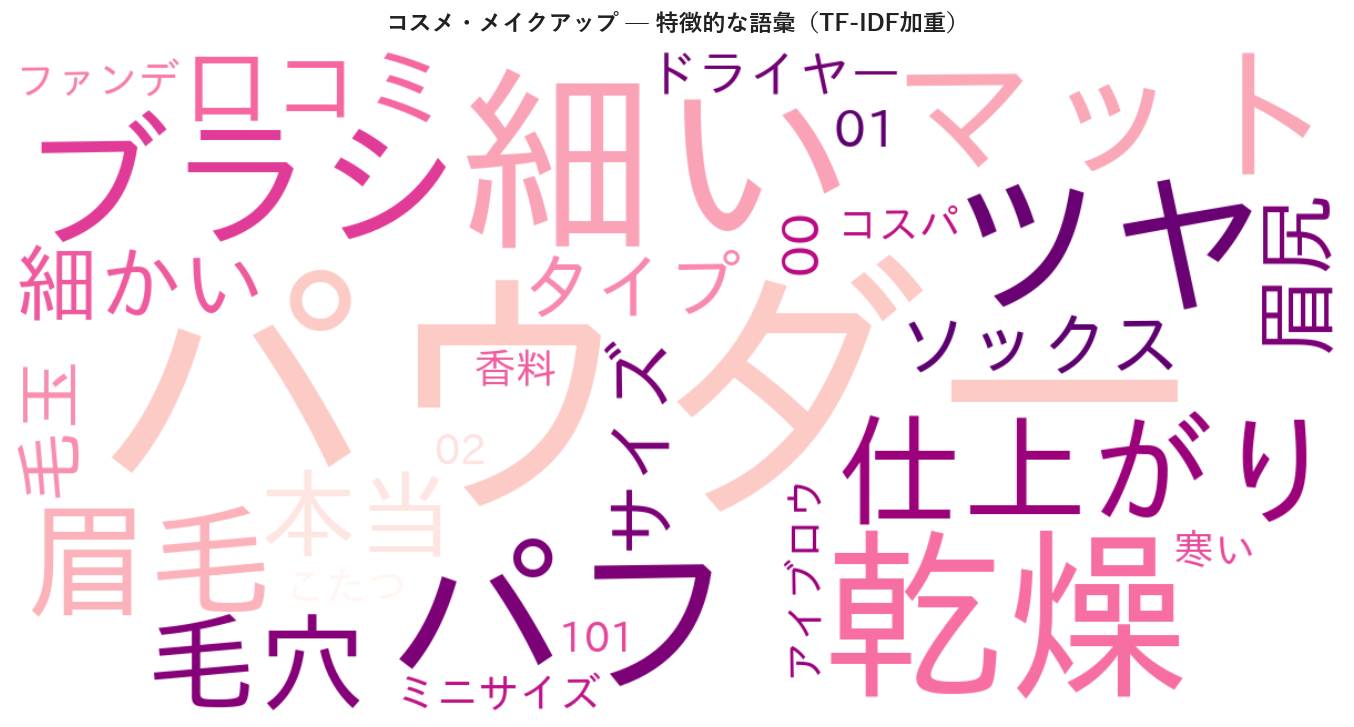

In [17]:
from src.viz import wordcloud_jp

# ── Note on top-N cutoff ──────────────────────────────────────────────────
# 40 terms: enough richness for a readable cloud, few enough that
# each word is large and legible for publication on note.com / LinkedIn.
# Increase to 60 if you want a denser academic-style cloud.

skin_freq = dict(skin_top[:40])
wordcloud_jp(
    skin_freq,
    title="スキンケア — 特徴的な語彙（TF-IDF加重）",
    colormap="Blues",
    output_path="../outputs/nb04_wordcloud_skincare.png",
    max_words=40,
    min_font_size=14,
)

cosm_freq = dict(cosm_top[:40])
wordcloud_jp(
    cosm_freq,
    title="コスメ・メイクアップ — 特徴的な語彙（TF-IDF加重）",
    colormap="RdPu",
    output_path="../outputs/nb04_wordcloud_cosmetics.png",
    max_words=40,
    min_font_size=14,
)


## 8. Consumer Voice Summary


In [18]:
# Pre/post boundary consistent with Section 5: <= 2019 pre, >= 2021 post
# 2020 excluded as transition year throughout this notebook
from IPython.display import display, Markdown

pre_rate  = ing_yr[ing_yr.review_year <= 2019]['ing_pct'].mean()
post_rate = ing_yr[ing_yr.review_year >= 2021]['ing_pct'].mean()

pre_len  = df_quality[
    (df_quality.tier == 'skincare') & (df_quality.review_year <= 2019)
]['avg_chars'].mean()
post_len = df_quality[
    (df_quality.tier == 'skincare') & (df_quality.review_year >= 2021)
]['avg_chars'].mean()

rate_arrow = '↑' if post_rate > pre_rate else '↓'
len_arrow  = '↑' if post_len > pre_len else '↓'

display(Markdown(f"""
## NB04 — Consumer Voice: Findings

---

### 1. Vocabulary contrast (TF-IDF)

**Skincare** vocabulary centres on ingredient names, routine steps, and function-focused language
— *{skin_top[0][0]}*, *{skin_top[1][0]}*, *{skin_top[2][0]}*.

**Cosmetics** vocabulary centres on colour/texture, application technique, and finish-focused language
— *{cosm_top[0][0]}*, *{cosm_top[1][0]}*, *{cosm_top[2][0]}*.

The two tiers speak measurably different languages — but this gap is narrowing (see NB06).

### 2. Vocabulary shift (≤2019 vs ≥2021, 2020 excluded)

| Direction | Top term | TF-IDF Δ |
|---|---|---|
| Rising | {emerging[0][0]} | {emerging[0][1]:+.4f} |
| Declining | {declining[0][0]} | {declining[0][1]:+.4f} |

### 3. Ingredient intelligence

| Window | Ingredient mention rate |
|---|---|
| Pre-COVID (≤2019) | {pre_rate:.1f}% of skincare reviews |
| Post-COVID (≥2021) | {post_rate:.1f}% {rate_arrow} |

### 4. Review engagement

| Window | Avg review length |
|---|---|
| Pre-COVID (≤2019) | {pre_len:.0f} chars |
| Post-COVID (≥2021) | {post_len:.0f} chars {len_arrow} |

---

**→ NB05:** These vocabulary findings strengthen the volume-based shift analysis with qualitative signal.
Review volume growth itself is a market signal, not a sampling artefact.
"""))


## NB04 — Consumer Voice: Findings

---

### 1. Vocabulary contrast (TF-IDF)

**Skincare** vocabulary centres on ingredient names, routine steps, and function-focused language
— *香り*, *乾燥*, *保湿*.

**Cosmetics** vocabulary centres on colour/texture, application technique, and finish-focused language
— *パウダー*, *細い*, *乾燥*.

The two tiers speak measurably different languages — but this gap is narrowing (see NB06).

### 2. Vocabulary shift (≤2019 vs ≥2021, 2020 excluded)

| Direction | Top term | TF-IDF Δ |
|---|---|---|
| Rising | クリーム | +0.0148 |
| Declining | カール | -0.0495 |

### 3. Ingredient intelligence

| Window | Ingredient mention rate |
|---|---|
| Pre-COVID (≤2019) | 5.5% of skincare reviews |
| Post-COVID (≥2021) | 8.7% ↑ |

### 4. Review engagement

| Window | Avg review length |
|---|---|
| Pre-COVID (≤2019) | 79 chars |
| Post-COVID (≥2021) | 72 chars ↓ |

---

**→ NB05:** These vocabulary findings strengthen the volume-based shift analysis with qualitative signal.
Review volume growth itself is a market signal, not a sampling artefact.


In [19]:
conn.close()
print()
print('=' * 60)
print('NB04 — Japanese Consumer Voice: COMPLETE')
print('=' * 60)
print('Proceed to NB05 — The Shift (Confirmatory Analysis)')



NB04 — Japanese Consumer Voice: COMPLETE
Proceed to NB05 — The Shift (Confirmatory Analysis)
